In [1]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler

from catboost import CatBoostRegressor, Pool
import lightgbm as lgb
from lightgbm import LGBMRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from pygam import LinearGAM, s, l, f


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")


In [27]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path.cwd() / "notebook_exports"
ROUND_DATA_PATH = OUTPUT_DIR / "round_level_modeling_dataset_v1.parquet"

TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
RANDOM_STATE = 42

USE_LAYOUT_ID = False
USE_DIVISION = True
REQUIRE_WEATHER_AVAILABLE = True
MIN_HOLES_PLAYED = 18

MPH_TO_MPS = 0.44704
MPS_TO_MPH = 2.23694

TARGET_COL = "actual_round_strokes"

# Fixed reporting / counterfactual reference conditions.
REFERENCE_WIND_MPH = 0.0
REFERENCE_WIND_GUST_MPH = 1.0
REFERENCE_TEMPERATURE_F = 80.0
REFERENCE_TEMPERATURE_C = (REFERENCE_TEMPERATURE_F - 32.0) * 5.0 / 9.0
REFERENCE_PRECIP_FLAG = 0

# Stage 1: baseline score model with no weather features.
STAGE1_CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 10000,
    "depth": 6,
    "learning_rate": 0.03,
    "l2_leaf_reg": 8.0,
    "random_seed": RANDOM_STATE,
    "verbose": 250,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}
STAGE1_EARLY_STOPPING_ROUNDS = 300

# Stage 2 shared feature setup.
STAGE2_SPLINE_FEATURES = [
    "round_wind_speed_mps_mean",
    "round_wind_gust_mps_mean",
    "round_temp_c_mean",
]

STAGE2_LINEAR_FEATURES = [
    "precip_during_round_flag",
    "wind_x_round_total_hole_length_k",
    "wind_x_round_length_over_par",
    "gust_x_round_total_hole_length_k",
]

STAGE2_FEATURE_COLS = STAGE2_SPLINE_FEATURES + STAGE2_LINEAR_FEATURES

# Monotone constraints for tree-based Stage 2 models.
# +1 means prediction must be non-decreasing as the feature increases.
#  0 means unconstrained.
STAGE2_MONOTONE_CONSTRAINT_MAP = {
    "round_wind_speed_mps_mean": 1,
    "round_wind_gust_mps_mean": 1,
    "round_temp_c_mean": 0,
    "precip_during_round_flag": 0,
    "wind_x_round_total_hole_length_k": 0,
    "wind_x_round_length_over_par": 0,
    "gust_x_round_total_hole_length_k": 0,
}
STAGE2_MONOTONE_CONSTRAINTS = [
    STAGE2_MONOTONE_CONSTRAINT_MAP[feature]
    for feature in STAGE2_FEATURE_COLS
]

STAGE2_RIDGE_ALPHAS = np.logspace(-3, 3, 25)
STAGE2_SPLINE_N_KNOTS = 7

STAGE2_CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 4000,
    "depth": 4,
    "learning_rate": 0.03,
    "l2_leaf_reg": 10.0,
    "random_seed": RANDOM_STATE,
    "verbose": 250,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "task_type": "CPU",
}
STAGE2_CATBOOST_EARLY_STOPPING_ROUNDS = 200

STAGE2_LIGHTGBM_PARAMS = {
    "objective": "regression",
    "metric": "rmse",
    "n_estimators": 4000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_lambda": 10.0,
    "random_state": RANDOM_STATE,
    "verbosity": -1,
    "monotone_constraints": STAGE2_MONOTONE_CONSTRAINTS,
}

STAGE2_LIGHTGBM_EARLY_STOPPING_ROUNDS = 200

STAGE2_XGBOOST_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 4000,
    "learning_rate": 0.03,
    "max_depth": 4,
    "min_child_weight": 1.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 10.0,
    "random_state": RANDOM_STATE,
    "tree_method": "hist",
    "monotone_constraints": tuple(STAGE2_MONOTONE_CONSTRAINTS),
}

STAGE2_XGBOOST_EARLY_STOPPING_ROUNDS = 200

STAGE2_GAM_LAM_GRID = np.logspace(-2, 2, 8)

EXPERIMENT_NAME = "v4_round_catboost_two_stage_compare_stage2_models"

print("Using local round dataset:", ROUND_DATA_PATH)
print("Reference wind (mph):", REFERENCE_WIND_MPH)
print("Reference gust (mph):", REFERENCE_WIND_GUST_MPH)
print("Reference temperature (F):", REFERENCE_TEMPERATURE_F)
print("Reference precip flag:", REFERENCE_PRECIP_FLAG)
print("MIN_HOLES_PLAYED:", MIN_HOLES_PLAYED)

display(
    pd.DataFrame(
        {
            "feature": STAGE2_FEATURE_COLS,
            "monotone_constraint": STAGE2_MONOTONE_CONSTRAINTS,
        }
    )
)


Using local round dataset: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\round_level_modeling_dataset_v1.parquet
Reference wind (mph): 0.0
Reference gust (mph): 1.0
Reference temperature (F): 80.0
Reference precip flag: 0
MIN_HOLES_PLAYED: 18


,feature,monotone_constraint
0,round_wind_speed_mps_mean,1
1,round_wind_gust_mps_mean,1
2,round_temp_c_mean,0
3,precip_during_round_flag,0
4,wind_x_round_total_hole_length_k,0
5,wind_x_round_length_over_par,0
6,gust_x_round_total_hole_length_k,0


In [3]:
# -----------------------------------------------------------------------------
# Load data
# -----------------------------------------------------------------------------

round_level_df = pd.read_parquet(ROUND_DATA_PATH).copy()
print("Round-level shape:", round_level_df.shape)
round_level_df.head()


Round-level shape: (419842, 28)


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating
0,2025,90004,1,PDGA#240866,248066,731340,MA4,777.0,60.0,18,4262.0,236.777778,54.0,3.000000,2.99,2.99,5.3,5.3,15.6,0.0,0.0,1018.5,82.0,6.0,78.925926,12743.38,22588.6,2323.23
1,2025,90022,1,PDGA#139372,303386,708703,MPO,944.0,65.0,22,6640.0,301.818182,69.0,3.136364,0.69,0.69,3.0,3.0,3.7,0.0,0.0,1009.0,83.0,-4.0,96.231884,4581.60,19920.0,651.36
2,2025,90022,1,PDGA#178707,303386,708703,FPO,921.0,67.0,22,6640.0,301.818182,69.0,3.136364,1.38,1.38,2.7,2.7,1.1,0.0,0.0,1009.0,91.0,-2.0,96.231884,9163.20,17928.0,1270.98
3,2025,90022,1,PDGA#235527,303386,708703,MA2,861.0,72.0,22,6640.0,301.818182,69.0,3.136364,1.25,1.25,2.3,2.3,2.2,0.0,0.0,1009.7,89.0,3.0,96.231884,8300.00,15272.0,1076.25
4,2025,90022,2,PDGA#208891,303386,708709,MA50,887.0,79.0,22,7337.0,333.500000,70.0,3.181818,1.71,1.71,4.2,4.2,5.5,0.0,0.0,1004.7,77.0,9.0,104.814286,12546.27,30815.4,1516.77


In [13]:
# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def total_variation(values: pd.Series) -> float:
    diffs = np.diff(values.to_numpy(dtype=float))
    return float(np.abs(diffs).sum())


def second_difference_roughness(values: pd.Series) -> float:
    arr = values.to_numpy(dtype=float)
    if len(arr) < 3:
        return 0.0
    return float(np.abs(np.diff(arr, n=2)).sum())


def nonmonotone_steps(values: pd.Series, *, tolerance: float = 0.10) -> int:
    arr = values.to_numpy(dtype=float)
    if len(arr) < 2:
        return 0
    return int((np.diff(arr) < -tolerance).sum())


def analysis_wind_bucket_from_mph(speed_mph: float | None) -> str:
    if speed_mph is None or pd.isna(speed_mph):
        return "unknown"
    if speed_mph < 3:
        return "0-3"
    if speed_mph < 6:
        return "3-6"
    if speed_mph < 9:
        return "6-9"
    if speed_mph < 12:
        return "9-12"
    if speed_mph < 15:
        return "12-15"
    return "15+"


def analysis_temp_bucket_from_f(temp_f: float | None) -> str:
    if temp_f is None or pd.isna(temp_f):
        return "unknown"
    if temp_f < 30:
        return "<30"
    if temp_f < 40:
        return "30-40"
    if temp_f < 50:
        return "40-50"
    if temp_f < 60:
        return "50-60"
    if temp_f < 70:
        return "60-70"
    if temp_f < 80:
        return "70-80"
    return "80+"


OBSERVED_WIND_BUCKETS = ["0-3", "3-6", "6-9", "9-12", "12-15", "15+"]
OBSERVED_TEMP_BUCKETS = ["<30", "30-40", "40-50", "50-60", "60-70", "70-80", "80+"]


def prepare_two_stage_frame(
    df: pd.DataFrame,
    *,
    stage1_numeric_features: list[str],
    stage1_categorical_features: list[str],
    stage2_raw_numeric_features: list[str],
    target_col: str,
    min_holes_played: int,
) -> pd.DataFrame:
    out = df.copy()

    if REQUIRE_WEATHER_AVAILABLE and "weather_available_flag" in out.columns:
        out = out[out["weather_available_flag"] == True].copy()  # noqa: E712

    if "hole_count" in out.columns:
        out["hole_count"] = pd.to_numeric(out["hole_count"], errors="coerce")
        out = out[out["hole_count"] >= min_holes_played].copy()

    required_cols = (
        [target_col]
        + stage1_numeric_features
        + stage1_categorical_features
        + stage2_raw_numeric_features
    )
    missing = [c for c in required_cols if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    numeric_cols = [target_col] + stage1_numeric_features + stage2_raw_numeric_features
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).copy()

    for col in stage1_categorical_features:
        out[col] = out[col].astype("string").fillna("__MISSING__").astype(str)

    out["round_wind_speed_mph_mean"] = out["round_wind_speed_mps_mean"] * MPS_TO_MPH
    out["round_wind_gust_mph_mean"] = out["round_wind_gust_mps_mean"] * MPS_TO_MPH
    out["round_temp_f_mean"] = (out["round_temp_c_mean"] * 9.0 / 5.0) + 32.0

    out["precip_during_round_flag"] = (
        pd.to_numeric(out["round_precip_mm_sum"], errors="coerce")
        .fillna(0.0)
        .gt(0.0)
        .astype(int)
    )

    out["observed_wind_bucket"] = out["round_wind_speed_mph_mean"].map(analysis_wind_bucket_from_mph)
    out["observed_temp_bucket"] = out["round_temp_f_mean"].map(analysis_temp_bucket_from_f)

    return out


def build_stage1_pool(
    df: pd.DataFrame,
    *,
    stage1_feature_cols: list[str],
    stage1_categorical_features: list[str],
    target_col: str | None = None,
) -> Pool:
    cat_idx = [stage1_feature_cols.index(c) for c in stage1_categorical_features]

    if target_col is not None:
        return Pool(
            data=df[stage1_feature_cols],
            label=df[target_col],
            cat_features=cat_idx,
        )

    return Pool(
        data=df[stage1_feature_cols],
        cat_features=cat_idx,
    )


def build_stage2_design_df(
    base_df: pd.DataFrame,
    *,
    wind_speed_mps: float | None = None,
    wind_gust_mps: float | None = None,
    temp_c: float | None = None,
    precip_flag: int | None = None,
) -> pd.DataFrame:
    out = pd.DataFrame(index=base_df.index)

    out["round_wind_speed_mps_mean"] = (
        wind_speed_mps
        if wind_speed_mps is not None
        else pd.to_numeric(base_df["round_wind_speed_mps_mean"], errors="coerce")
    )
    out["round_wind_gust_mps_mean"] = (
        wind_gust_mps
        if wind_gust_mps is not None
        else pd.to_numeric(base_df["round_wind_gust_mps_mean"], errors="coerce")
    )
    out["round_temp_c_mean"] = (
        temp_c
        if temp_c is not None
        else pd.to_numeric(base_df["round_temp_c_mean"], errors="coerce")
    )
    out["precip_during_round_flag"] = (
        precip_flag
        if precip_flag is not None
        else pd.to_numeric(base_df["precip_during_round_flag"], errors="coerce").fillna(0).astype(int)
    )

    round_total_hole_length = pd.to_numeric(base_df["round_total_hole_length"], errors="coerce")
    round_length_over_par = pd.to_numeric(base_df["round_length_over_par"], errors="coerce")

    round_total_hole_length_k = round_total_hole_length / 1000.0

    out["wind_x_round_total_hole_length_k"] = out["round_wind_speed_mps_mean"] * round_total_hole_length_k
    out["wind_x_round_length_over_par"] = out["round_wind_speed_mps_mean"] * round_length_over_par
    out["gust_x_round_total_hole_length_k"] = out["round_wind_gust_mps_mean"] * round_total_hole_length_k

    design_df = out[STAGE2_FEATURE_COLS].copy()
    return design_df


def build_effect_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric in [
        "estimated_wind_effect_vs_reference",
        "estimated_temperature_effect_vs_reference",
        "estimated_precip_effect_vs_reference",
        "estimated_total_weather_effect_vs_reference",
    ]:
        rows.append(
            {
                "metric": metric,
                "mean": float(df[metric].mean()),
                "median": float(df[metric].median()),
                "std": float(df[metric].std()),
                "p10": float(df[metric].quantile(0.10)),
                "p90": float(df[metric].quantile(0.90)),
            }
        )
    return pd.DataFrame(rows)


def predict_stage2_model(model_name: str, fitted_model, X: pd.DataFrame) -> np.ndarray:
    if model_name == "gam_style":
        return np.asarray(fitted_model.predict(X.to_numpy())).reshape(-1)

    if model_name in {
        "spline_ridge",
        "catboost_residual",
        "lightgbm_residual_monotone",
        "xgboost_residual_monotone",
    }:
        return np.asarray(fitted_model.predict(X)).reshape(-1)

    raise ValueError(f"Unsupported model_name: {model_name}")


def fit_stage2_lightgbm_residual(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
):
    if LGBMRegressor is None or lgb is None:
        raise ImportError(
            "lightgbm is not installed. Install it with `pip install lightgbm` or run the optional install cell."
        )

    model = LGBMRegressor(**STAGE2_LIGHTGBM_PARAMS)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(STAGE2_LIGHTGBM_EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(250),
        ],
    )

    fit_meta = {
        "best_iteration": getattr(model, "best_iteration_", None),
        "model_family": "lightgbm_residual",
    }
    return model, fit_meta

def fit_stage2_xgboost_residual(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
):
    if XGBRegressor is None or xgb is None:
        raise ImportError(
            "xgboost is not installed. Install it with `pip install xgboost` or run the optional install cell."
        )

    model = XGBRegressor(**STAGE2_XGBOOST_PARAMS)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=250,
    )

    fit_meta = {
        "best_iteration": getattr(model, "best_iteration", None),
        "model_family": "xgboost_residual",
    }
    return model, fit_meta

def build_stage2_effect_curve(
    *,
    model_name: str,
    stage2_model,
    base_df: pd.DataFrame,
    build_actual_design_fn,
    build_reference_design_fn,
    grid_values: list[float],
) -> pd.DataFrame:
    rows = []

    for grid_value in grid_values:
        actual_design = build_actual_design_fn(base_df.copy(), grid_value)
        reference_design = build_reference_design_fn(base_df.copy(), grid_value)

        actual_pred = predict_stage2_model(model_name, stage2_model, actual_design)
        reference_pred = predict_stage2_model(model_name, stage2_model, reference_design)
        effect_values = actual_pred - reference_pred

        rows.append(
            {
                "grid_value": grid_value,
                "effect_mean": float(np.mean(effect_values)),
                "effect_median": float(np.median(effect_values)),
                "effect_std": float(np.std(effect_values)),
                "effect_p10": float(np.quantile(effect_values, 0.10)),
                "effect_p90": float(np.quantile(effect_values, 0.90)),
            }
        )

    return pd.DataFrame(rows)


In [5]:
# -----------------------------------------------------------------------------
# Feature setup
# -----------------------------------------------------------------------------

model_df = round_level_df.copy()

STAGE1_NUMERIC_FEATURES = [
    "player_rating",
    "round_number",
    "hole_count",
    "round_total_hole_length",
    "round_avg_hole_length",
    "round_total_par",
    "round_avg_hole_par",
    "round_length_over_par",
]

STAGE1_CATEGORICAL_FEATURES = [
    "course_id",
]

if USE_DIVISION:
    STAGE1_CATEGORICAL_FEATURES.append("division")

if USE_LAYOUT_ID:
    STAGE1_CATEGORICAL_FEATURES.append("layout_id")

STAGE2_RAW_NUMERIC_FEATURES = [
    "round_wind_speed_mps_mean",
    "round_wind_gust_mps_mean",
    "round_temp_c_mean",
    "round_precip_mm_sum",
]

print("Stage 1 numeric features:", STAGE1_NUMERIC_FEATURES)
print("Stage 1 categorical features:", STAGE1_CATEGORICAL_FEATURES)
print("Stage 2 raw numeric features:", STAGE2_RAW_NUMERIC_FEATURES)
print("Stage 2 design features:", STAGE2_FEATURE_COLS)


Stage 1 numeric features: ['player_rating', 'round_number', 'hole_count', 'round_total_hole_length', 'round_avg_hole_length', 'round_total_par', 'round_avg_hole_par', 'round_length_over_par']
Stage 1 categorical features: ['course_id', 'division']
Stage 2 raw numeric features: ['round_wind_speed_mps_mean', 'round_wind_gust_mps_mean', 'round_temp_c_mean', 'round_precip_mm_sum']
Stage 2 design features: ['round_wind_speed_mps_mean', 'round_wind_gust_mps_mean', 'round_temp_c_mean', 'precip_during_round_flag', 'wind_x_round_total_hole_length_k', 'wind_x_round_length_over_par', 'gust_x_round_total_hole_length_k']


In [6]:
# -----------------------------------------------------------------------------
# Train / validation / test split
# -----------------------------------------------------------------------------

train_full_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df, valid_df = train_test_split(
    train_full_df,
    test_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
)

train_prepped = prepare_two_stage_frame(
    train_df,
    stage1_numeric_features=STAGE1_NUMERIC_FEATURES,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    stage2_raw_numeric_features=STAGE2_RAW_NUMERIC_FEATURES,
    target_col=TARGET_COL,
    min_holes_played=MIN_HOLES_PLAYED,
)
valid_prepped = prepare_two_stage_frame(
    valid_df,
    stage1_numeric_features=STAGE1_NUMERIC_FEATURES,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    stage2_raw_numeric_features=STAGE2_RAW_NUMERIC_FEATURES,
    target_col=TARGET_COL,
    min_holes_played=MIN_HOLES_PLAYED,
)
test_prepped = prepare_two_stage_frame(
    test_df,
    stage1_numeric_features=STAGE1_NUMERIC_FEATURES,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    stage2_raw_numeric_features=STAGE2_RAW_NUMERIC_FEATURES,
    target_col=TARGET_COL,
    min_holes_played=MIN_HOLES_PLAYED,
)

print("Train rows:", len(train_prepped))
print("Valid rows:", len(valid_prepped))
print("Test rows:", len(test_prepped))


Train rows: 264129
Valid rows: 66031
Test rows: 82511


In [7]:
# -----------------------------------------------------------------------------
# Stage 1 baseline model
# -----------------------------------------------------------------------------

stage1_feature_cols = STAGE1_NUMERIC_FEATURES + STAGE1_CATEGORICAL_FEATURES

stage1_train_pool = build_stage1_pool(
    train_prepped,
    stage1_feature_cols=stage1_feature_cols,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)
stage1_valid_pool = build_stage1_pool(
    valid_prepped,
    stage1_feature_cols=stage1_feature_cols,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)
stage1_test_pool = build_stage1_pool(
    test_prepped,
    stage1_feature_cols=stage1_feature_cols,
    stage1_categorical_features=STAGE1_CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)

stage1_model = CatBoostRegressor(**STAGE1_CATBOOST_PARAMS)
stage1_model.fit(
    stage1_train_pool,
    eval_set=stage1_valid_pool,
    use_best_model=True,
    early_stopping_rounds=STAGE1_EARLY_STOPPING_ROUNDS,
)

stage1_best_iteration = getattr(stage1_model, "best_iteration_", None)

train_stage1_pred = stage1_model.predict(stage1_train_pool)
valid_stage1_pred = stage1_model.predict(stage1_valid_pool)
test_stage1_pred = stage1_model.predict(stage1_test_pool)

stage1_metrics_df = pd.DataFrame(
    [
        {"split": "train", **regression_metrics(train_prepped[TARGET_COL], train_stage1_pred)},
        {"split": "valid", **regression_metrics(valid_prepped[TARGET_COL], valid_stage1_pred)},
        {"split": "test", **regression_metrics(test_prepped[TARGET_COL], test_stage1_pred)},
    ]
)
stage1_metrics_df["model"] = "stage1_baseline"
stage1_metrics_df["best_iteration"] = stage1_best_iteration
stage1_metrics_df["feature_count"] = len(stage1_feature_cols)

stage1_metrics_df


0:	learn: 9.9218432	test: 9.8473899	best: 9.8473899 (0)	total: 241ms	remaining: 40m 13s
250:	learn: 4.5898817	test: 4.5104694	best: 4.5104694 (250)	total: 22.9s	remaining: 14m 51s
500:	learn: 4.4479042	test: 4.3675956	best: 4.3675956 (500)	total: 45.7s	remaining: 14m 26s
750:	learn: 4.3841156	test: 4.3069650	best: 4.3069650 (750)	total: 1m 8s	remaining: 14m 5s
1000:	learn: 4.3409226	test: 4.2667125	best: 4.2667125 (1000)	total: 1m 30s	remaining: 13m 38s
1250:	learn: 4.3076567	test: 4.2365358	best: 4.2365358 (1250)	total: 1m 53s	remaining: 13m 14s
1500:	learn: 4.2802139	test: 4.2125776	best: 4.2125776 (1500)	total: 2m 16s	remaining: 12m 53s
1750:	learn: 4.2557537	test: 4.1920731	best: 4.1920731 (1750)	total: 2m 38s	remaining: 12m 28s
2000:	learn: 4.2344382	test: 4.1739082	best: 4.1739082 (2000)	total: 3m 1s	remaining: 12m 6s
2250:	learn: 4.2147336	test: 4.1576003	best: 4.1576003 (2250)	total: 3m 24s	remaining: 11m 43s
2500:	learn: 4.1968041	test: 4.1430552	best: 4.1430552 (2500)	total: 

,split,mae,rmse,r2,model,best_iteration,feature_count
0,train,2.950979,3.886290,0.851902,stage1_baseline,9999,10
1,valid,3.032076,3.947328,0.844923,stage1_baseline,9999,10
2,test,3.061831,4.021947,0.840866,stage1_baseline,9999,10


In [8]:
# -----------------------------------------------------------------------------
# Stage 1 feature importance
# -----------------------------------------------------------------------------

stage1_feature_importance_df = stage1_model.get_feature_importance(
    stage1_train_pool,
    prettified=True,
).rename(columns={"Feature Id": "feature", "Importances": "importance"})

stage1_feature_importance_df.head(25)


,feature,importance
0,round_total_par,32.647181
1,player_rating,29.039331
2,round_length_over_par,11.356177
3,round_total_hole_length,7.742291
4,round_avg_hole_par,6.851201
5,course_id,5.865694
6,round_avg_hole_length,3.921522
7,division,0.955603
8,round_number,0.832109
9,hole_count,0.788891


In [9]:
# -----------------------------------------------------------------------------
# Build stage 2 residual targets and design matrices
# -----------------------------------------------------------------------------

train_residual_target = train_prepped[TARGET_COL] - train_stage1_pred
valid_residual_target = valid_prepped[TARGET_COL] - valid_stage1_pred
test_residual_target = test_prepped[TARGET_COL] - test_stage1_pred

X_stage2_train = build_stage2_design_df(train_prepped)
X_stage2_valid = build_stage2_design_df(valid_prepped)
X_stage2_test = build_stage2_design_df(test_prepped)

display(X_stage2_train.head())
display(train_residual_target.head())


,round_wind_speed_mps_mean,round_wind_gust_mps_mean,round_temp_c_mean,precip_during_round_flag,wind_x_round_total_hole_length_k,wind_x_round_length_over_par,gust_x_round_total_hole_length_k
162475,2.61,6.9,24.9,0,4.42395,73.732500,11.6955
2395,1.68,3.1,21.0,0,8.76288,156.480000,16.1696
86847,1.30,4.4,11.9,0,10.72630,132.423457,36.3044
402157,2.33,3.9,2.3,0,19.42055,298.777692,32.5065
154397,1.86,3.6,26.2,0,9.27954,168.718909,17.9604


162475   -0.883198
2395     -3.340318
86847     1.672844
402157   -2.789211
154397    2.591499
Name: actual_round_strokes, dtype: float64

In [12]:
# -----------------------------------------------------------------------------
# Stage 2 model builders
# -----------------------------------------------------------------------------

def fit_stage2_spline_ridge(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "weather_splines",
                SplineTransformer(
                    n_knots=STAGE2_SPLINE_N_KNOTS,
                    degree=3,
                    include_bias=False,
                    extrapolation="constant",
                ),
                STAGE2_SPLINE_FEATURES,
            ),
            (
                "linear_terms",
                StandardScaler(),
                STAGE2_LINEAR_FEATURES,
            ),
        ],
        remainder="drop",
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ridge", RidgeCV(alphas=STAGE2_RIDGE_ALPHAS)),
        ]
    )

    model.fit(X_train, y_train)

    fit_meta = {
        "selected_alpha": float(model.named_steps["ridge"].alpha_),
        "model_family": "spline_ridge",
    }
    return model, fit_meta


def fit_stage2_gam_style(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
):
    if LinearGAM is None:
        raise ImportError(
            "pygam is not installed. Install it with `pip install pygam` or run the optional install cell."
        )

    # Column order in STAGE2_FEATURE_COLS:
    # 0 wind_speed, 1 wind_gust, 2 temp, 3 precip_flag, 4 wind_x_len, 5 wind_x_lop, 6 gust_x_len
    gam_terms = (
        s(0) +
        s(1) +
        s(2) +
        f(3) +
        l(4) +
        l(5) +
        l(6)
    )

    model = LinearGAM(gam_terms)
    model.gridsearch(
        X_train.to_numpy(),
        y_train.to_numpy(),
        lam=STAGE2_GAM_LAM_GRID,
        progress=False,
    )

    fit_meta = {
        "selected_lam": json.dumps(model.lam),
        "model_family": "gam_style",
    }
    return model, fit_meta


def fit_stage2_catboost_residual(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
):
    cat_features = [X_train.columns.get_loc("precip_during_round_flag")]

    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_features,
    )
    valid_pool = Pool(
        data=X_valid,
        label=y_valid,
        cat_features=cat_features,
    )

    model = CatBoostRegressor(**STAGE2_CATBOOST_PARAMS)
    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
        early_stopping_rounds=STAGE2_CATBOOST_EARLY_STOPPING_ROUNDS,
    )

    fit_meta = {
        "best_iteration": getattr(model, "best_iteration_", None),
        "model_family": "catboost_residual",
    }
    return model, fit_meta


def fit_stage2_lightgbm_residual(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
):
    if LGBMRegressor is None or lgb is None:
        raise ImportError(
            "lightgbm is not installed. Install it with `pip install lightgbm` or run the optional install cell."
        )

    model = LGBMRegressor(**STAGE2_LIGHTGBM_PARAMS)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(STAGE2_LIGHTGBM_EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(250),
        ],
    )

    fit_meta = {
        "best_iteration": getattr(model, "best_iteration_", None),
        "model_family": "lightgbm_residual_monotone",
        "monotone_constraints": STAGE2_MONOTONE_CONSTRAINTS,
    }
    return model, fit_meta


def fit_stage2_xgboost_residual(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
):
    if XGBRegressor is None or xgb is None:
        raise ImportError(
            "xgboost is not installed. Install it with `pip install xgboost` or run the optional install cell."
        )

    model = XGBRegressor(**STAGE2_XGBOOST_PARAMS)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=250,
    )

    fit_meta = {
        "best_iteration": getattr(model, "best_iteration", None),
        "model_family": "xgboost_residual_monotone",
        "monotone_constraints": STAGE2_MONOTONE_CONSTRAINTS,
    }
    return model, fit_meta


In [14]:
# -----------------------------------------------------------------------------
# Fit all Stage 2 models
# -----------------------------------------------------------------------------

stage2_model_fitters = {
    "spline_ridge": fit_stage2_spline_ridge,
    "gam_style": fit_stage2_gam_style,
    "catboost_residual": fit_stage2_catboost_residual,
    "lightgbm_residual_monotone": fit_stage2_lightgbm_residual,
    "xgboost_residual_monotone": fit_stage2_xgboost_residual,
}

stage2_results = {}

for model_name, fit_fn in stage2_model_fitters.items():
    print(f"Fitting Stage 2 model: {model_name}")

    fitted_model, fit_meta = fit_fn(
        X_stage2_train,
        train_residual_target,
        X_stage2_valid,
        valid_residual_target,
    )

    train_stage2_pred = predict_stage2_model(model_name, fitted_model, X_stage2_train)
    valid_stage2_pred = predict_stage2_model(model_name, fitted_model, X_stage2_valid)
    test_stage2_pred = predict_stage2_model(model_name, fitted_model, X_stage2_test)

    combined_train_pred = train_stage1_pred + train_stage2_pred
    combined_valid_pred = valid_stage1_pred + valid_stage2_pred
    combined_test_pred = test_stage1_pred + test_stage2_pred

    stage2_results[model_name] = {
        "model": fitted_model,
        "fit_meta": fit_meta,
        "train_stage2_pred": train_stage2_pred,
        "valid_stage2_pred": valid_stage2_pred,
        "test_stage2_pred": test_stage2_pred,
        "combined_train_pred": combined_train_pred,
        "combined_valid_pred": combined_valid_pred,
        "combined_test_pred": combined_test_pred,
    }

print("Finished fitting Stage 2 models.")
print("Models fit:", list(stage2_results.keys()))


Fitting Stage 2 model: spline_ridge
Fitting Stage 2 model: gam_style
Fitting Stage 2 model: catboost_residual
0:	learn: 3.8854390	test: 3.9464016	best: 3.9464016 (0)	total: 240ms	remaining: 16m
250:	learn: 3.8608727	test: 3.9198539	best: 3.9198539 (250)	total: 12.5s	remaining: 3m 6s
500:	learn: 3.8545709	test: 3.9145907	best: 3.9145907 (500)	total: 22.5s	remaining: 2m 37s
750:	learn: 3.8479232	test: 3.9097712	best: 3.9097712 (750)	total: 32.8s	remaining: 2m 21s
1000:	learn: 3.8422593	test: 3.9062087	best: 3.9062087 (1000)	total: 44.1s	remaining: 2m 12s
1250:	learn: 3.8371427	test: 3.9028831	best: 3.9028831 (1250)	total: 54.7s	remaining: 2m
1500:	learn: 3.8324752	test: 3.8998384	best: 3.8998384 (1500)	total: 1m 5s	remaining: 1m 49s
1750:	learn: 3.8280175	test: 3.8968980	best: 3.8968980 (1750)	total: 1m 15s	remaining: 1m 37s
2000:	learn: 3.8237744	test: 3.8941736	best: 3.8941736 (2000)	total: 1m 26s	remaining: 1m 26s
2250:	learn: 3.8197800	test: 3.8916138	best: 3.8916138 (2250)	total: 1m

In [15]:
# -----------------------------------------------------------------------------
# Compare Stage 2 models
# -----------------------------------------------------------------------------

stage2_comparison_rows = []

for model_name, result in stage2_results.items():
    train_stage2_pred = result["train_stage2_pred"]
    valid_stage2_pred = result["valid_stage2_pred"]
    test_stage2_pred = result["test_stage2_pred"]

    combined_train_pred = result["combined_train_pred"]
    combined_valid_pred = result["combined_valid_pred"]
    combined_test_pred = result["combined_test_pred"]

    row = {
        "stage2_model": model_name,
        "residual_train_rmse": float(np.sqrt(mean_squared_error(train_residual_target, train_stage2_pred))),
        "residual_valid_rmse": float(np.sqrt(mean_squared_error(valid_residual_target, valid_stage2_pred))),
        "residual_test_rmse": float(np.sqrt(mean_squared_error(test_residual_target, test_stage2_pred))),
        "combined_train_rmse": float(np.sqrt(mean_squared_error(train_prepped[TARGET_COL], combined_train_pred))),
        "combined_valid_rmse": float(np.sqrt(mean_squared_error(valid_prepped[TARGET_COL], combined_valid_pred))),
        "combined_test_rmse": float(np.sqrt(mean_squared_error(test_prepped[TARGET_COL], combined_test_pred))),
        "combined_valid_r2": float(r2_score(valid_prepped[TARGET_COL], combined_valid_pred)),
        "combined_test_r2": float(r2_score(test_prepped[TARGET_COL], combined_test_pred)),
        "fit_meta": json.dumps(result["fit_meta"]),
    }
    stage2_comparison_rows.append(row)

stage2_model_comparison_df = pd.DataFrame(stage2_comparison_rows).sort_values(
    ["combined_valid_rmse", "combined_test_rmse"],
    ascending=[True, True],
)

stage2_model_comparison_df


,stage2_model,residual_train_rmse,residual_valid_rmse,residual_test_rmse,combined_train_rmse,combined_valid_rmse,combined_test_rmse,combined_valid_r2,combined_test_r2,fit_meta
3,lightgbm_residual_monotone,3.618401,3.778134,3.854311,3.618401,3.778134,3.854311,0.857932,0.853855,"{""best_iteration"": 4000, ""model_family"": ""ligh..."
4,xgboost_residual_monotone,3.750635,3.850223,3.927927,3.750635,3.850223,3.927927,0.852459,0.848219,"{""best_iteration"": null, ""model_family"": ""xgbo..."
2,catboost_residual,3.796387,3.876897,3.953066,3.796387,3.876897,3.953066,0.850408,0.846270,"{""best_iteration"": 3999, ""model_family"": ""catb..."
1,gam_style,3.866395,3.925544,4.001882,3.866395,3.925544,4.001882,0.846630,0.842450,"{""selected_lam"": ""[[0.517947467923121], [0.517..."
0,spline_ridge,3.867482,3.926013,4.002324,3.867482,3.926013,4.002324,0.846594,0.842415,"{""selected_alpha"": 0.01, ""model_family"": ""spli..."


In [28]:
# -----------------------------------------------------------------------------
# Reference conditions summary
# -----------------------------------------------------------------------------

reference_conditions_df = pd.DataFrame(
    [
        {
            "wind_speed_reference_mph": REFERENCE_WIND_MPH,
            "wind_gust_reference_mph": REFERENCE_WIND_GUST_MPH,
            "temperature_reference_c": REFERENCE_TEMPERATURE_C,
            "temperature_reference_f": REFERENCE_TEMPERATURE_F,
            "precip_reference_flag": REFERENCE_PRECIP_FLAG,
        }
    ]
)

reference_conditions_df


,wind_speed_reference_mph,wind_gust_reference_mph,temperature_reference_c,temperature_reference_f,precip_reference_flag
0,0.0,1.0,26.666667,80.0,0


In [29]:
# -----------------------------------------------------------------------------
# Score test rows under observed weather for every Stage 2 model
# -----------------------------------------------------------------------------

def score_test_rows_for_stage2_model(
    *,
    model_name: str,
    fitted_model,
    test_prepped: pd.DataFrame,
    test_stage1_pred: np.ndarray,
) -> pd.DataFrame:
    scored_df = test_prepped.copy()

    observed_design_df = build_stage2_design_df(test_prepped)
    observed_weather_adj = predict_stage2_model(model_name, fitted_model, observed_design_df)

    wind_reference_design_df = build_stage2_design_df(
        test_prepped,
        wind_speed_mps=REFERENCE_WIND_MPH * MPH_TO_MPS,
        wind_gust_mps=REFERENCE_WIND_GUST_MPH * MPH_TO_MPS,
    )
    wind_reference_weather_adj = predict_stage2_model(model_name, fitted_model, wind_reference_design_df)

    temperature_reference_design_df = build_stage2_design_df(
        test_prepped,
        temp_c=REFERENCE_TEMPERATURE_C,
    )
    temperature_reference_weather_adj = predict_stage2_model(model_name, fitted_model, temperature_reference_design_df)

    precip_reference_design_df = build_stage2_design_df(
        test_prepped,
        precip_flag=REFERENCE_PRECIP_FLAG,
    )
    precip_reference_weather_adj = predict_stage2_model(model_name, fitted_model, precip_reference_design_df)

    total_weather_reference_design_df = build_stage2_design_df(
        test_prepped,
        wind_speed_mps=REFERENCE_WIND_MPH * MPH_TO_MPS,
        wind_gust_mps=REFERENCE_WIND_GUST_MPH * MPH_TO_MPS,
        temp_c=REFERENCE_TEMPERATURE_C,
        precip_flag=REFERENCE_PRECIP_FLAG,
    )
    total_weather_reference_weather_adj = predict_stage2_model(model_name, fitted_model, total_weather_reference_design_df)

    scored_df["stage2_model"] = model_name
    scored_df["predicted_round_strokes_stage1_baseline"] = test_stage1_pred
    scored_df["predicted_weather_adjustment_observed"] = observed_weather_adj
    scored_df["predicted_round_strokes"] = test_stage1_pred + observed_weather_adj
    scored_df["round_residual_strokes"] = scored_df["actual_round_strokes"] - scored_df["predicted_round_strokes"]

    scored_df["estimated_wind_effect_vs_reference"] = observed_weather_adj - wind_reference_weather_adj
    scored_df["estimated_temperature_effect_vs_reference"] = observed_weather_adj - temperature_reference_weather_adj
    scored_df["estimated_precip_effect_vs_reference"] = observed_weather_adj - precip_reference_weather_adj
    scored_df["estimated_total_weather_effect_vs_reference"] = observed_weather_adj - total_weather_reference_weather_adj

    return scored_df


scored_dfs_by_model = {}
weather_effect_summary_frames = []

for model_name, result in stage2_results.items():
    scored_df_model = score_test_rows_for_stage2_model(
        model_name=model_name,
        fitted_model=result["model"],
        test_prepped=test_prepped,
        test_stage1_pred=test_stage1_pred,
    )
    scored_dfs_by_model[model_name] = scored_df_model

    summary_df = build_effect_summary(scored_df_model)
    summary_df["stage2_model"] = model_name
    weather_effect_summary_frames.append(summary_df)

weather_effect_summary_by_model_df = pd.concat(
    weather_effect_summary_frames,
    ignore_index=True,
)

weather_effect_summary_by_model_df


,metric,mean,median,std,p10,p90,stage2_model
0,estimated_wind_effect_vs_reference,0.189487,0.088704,0.320498,-0.091362,0.639969,spline_ridge
1,estimated_temperature_effect_vs_reference,0.174075,0.149500,0.183027,0.016992,0.365479,spline_ridge
2,estimated_precip_effect_vs_reference,0.020255,0.000000,0.054522,0.000000,0.167013,spline_ridge
3,estimated_total_weather_effect_vs_reference,0.383817,0.292632,0.381069,0.014007,0.896238,spline_ridge
4,estimated_wind_effect_vs_reference,0.594526,0.491715,0.330162,0.303181,1.019425,gam_style
5,estimated_temperature_effect_vs_reference,0.196045,0.140672,0.189157,0.068376,0.412238,gam_style
6,estimated_precip_effect_vs_reference,0.019843,0.000000,0.053412,0.000000,0.163613,gam_style
7,estimated_total_weather_effect_vs_reference,0.810415,0.728719,0.391045,0.440723,1.307370,gam_style
8,estimated_wind_effect_vs_reference,1.622008,1.604561,0.732680,0.749411,2.500954,catboost_residual
9,estimated_temperature_effect_vs_reference,0.149072,0.122641,0.418289,-0.271333,0.614446,catboost_residual


In [30]:
# -----------------------------------------------------------------------------
# Wind bucket summary by Stage 2 model
# -----------------------------------------------------------------------------

wind_bucket_summary_frames = []

for model_name, scored_df_model in scored_dfs_by_model.items():
    wind_summary = (
        scored_df_model.groupby("observed_wind_bucket", dropna=False)
        .agg(
            rows=("player_rating", "size"),
            wind_speed_mph_mean=("round_wind_speed_mph_mean", "mean"),
            estimated_wind_effect_mean=("estimated_wind_effect_vs_reference", "mean"),
            estimated_total_weather_effect_mean=("estimated_total_weather_effect_vs_reference", "mean"),
        )
        .reset_index()
    )
    wind_summary["stage2_model"] = model_name
    wind_bucket_summary_frames.append(wind_summary)

wind_bucket_summary_by_model_df = pd.concat(
    wind_bucket_summary_frames,
    ignore_index=True,
)

wind_bucket_summary_by_model_df


,observed_wind_bucket,rows,wind_speed_mph_mean,estimated_wind_effect_mean,estimated_total_weather_effect_mean,stage2_model
0,0-3,17614,1.807141,-0.049230,0.141568,spline_ridge
1,12-15,4072,13.217113,0.869651,1.124793,spline_ridge
2,15+,2096,17.170115,1.194874,1.465883,spline_ridge
3,3-6,28464,4.503577,0.013863,0.193023,spline_ridge
4,6-9,20271,7.372077,0.232333,0.423312,spline_ridge
5,9-12,9994,10.277698,0.535518,0.745223,spline_ridge
6,0-3,17614,1.807141,0.352767,0.563394,gam_style
7,12-15,4072,13.217113,1.293533,1.567965,gam_style
8,15+,2096,17.170115,1.606493,1.896682,gam_style
9,3-6,28464,4.503577,0.415033,0.617208,gam_style


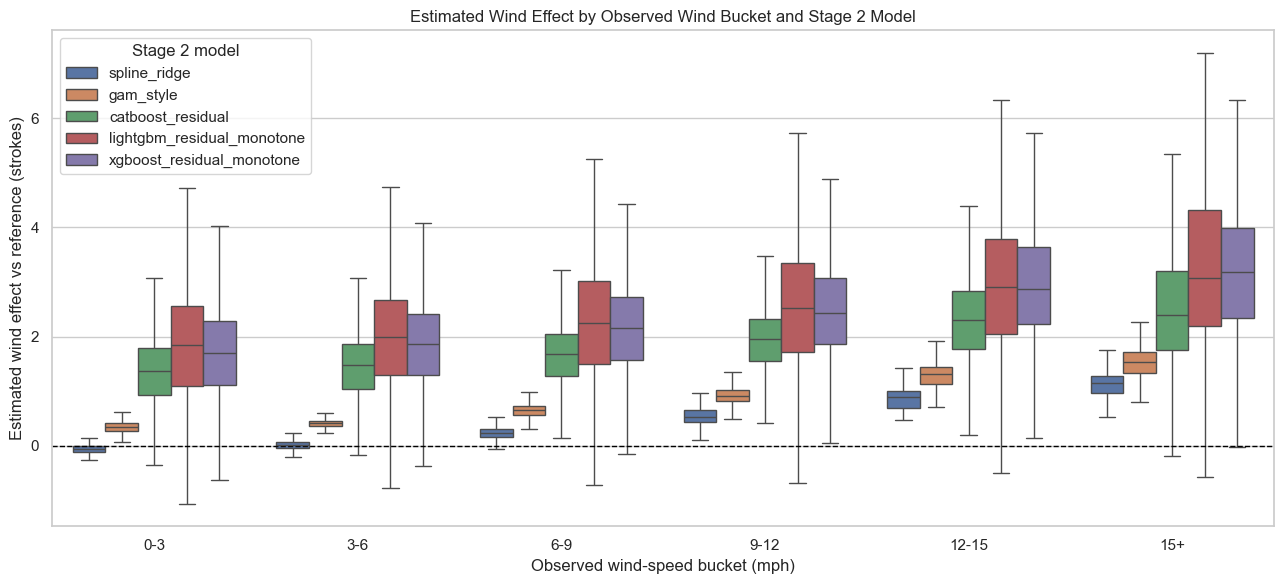

In [31]:
# -----------------------------------------------------------------------------
# Wind bucket boxplot comparing Stage 2 models
# -----------------------------------------------------------------------------

wind_effect_boxplot_frames = []

for model_name, scored_df_model in scored_dfs_by_model.items():
    tmp = scored_df_model.copy()
    tmp["observed_wind_bucket_str"] = tmp["observed_wind_bucket"].astype(str).str.strip()
    tmp["observed_wind_bucket_plot"] = pd.Categorical(
        tmp["observed_wind_bucket_str"],
        categories=OBSERVED_WIND_BUCKETS,
        ordered=True,
    )
    wind_effect_boxplot_frames.append(
        tmp[
            [
                "stage2_model",
                "observed_wind_bucket_plot",
                "estimated_wind_effect_vs_reference",
            ]
        ].copy()
    )

wind_effect_boxplot_compare_df = pd.concat(
    wind_effect_boxplot_frames,
    ignore_index=True,
)

plt.figure(figsize=(13, 6))
sns.boxplot(
    data=wind_effect_boxplot_compare_df,
    x="observed_wind_bucket_plot",
    y="estimated_wind_effect_vs_reference",
    hue="stage2_model",
    showfliers=False,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Estimated Wind Effect by Observed Wind Bucket and Stage 2 Model")
plt.xlabel("Observed wind-speed bucket (mph)")
plt.ylabel("Estimated wind effect vs reference (strokes)")
plt.legend(title="Stage 2 model")
plt.tight_layout()
plt.show()


In [32]:
# -----------------------------------------------------------------------------
# Counterfactual wind and temperature curves for every Stage 2 model
# -----------------------------------------------------------------------------

pdp_base_df = test_prepped.copy()

wind_grid_mph = [0, 2, 5, 8, 12, 16]
wind_grid_mps = [x * MPH_TO_MPS for x in wind_grid_mph]
REFERENCE_GUST_GAP_MPH = max(0.0, REFERENCE_WIND_GUST_MPH - REFERENCE_WIND_MPH)

temperature_grid_c = [0, 5, 10, 12, 15, 18, 21, 24, 27, 30]

def candidate_gust_from_wind_mph(wind_speed_mph: float) -> float:
    return max(wind_speed_mph, wind_speed_mph + REFERENCE_GUST_GAP_MPH)

def build_wind_actual_design(base_df: pd.DataFrame, grid_value_mps: float) -> pd.DataFrame:
    wind_speed_mph = grid_value_mps * MPS_TO_MPH
    wind_gust_mph = candidate_gust_from_wind_mph(wind_speed_mph)
    return build_stage2_design_df(
        base_df,
        wind_speed_mps=grid_value_mps,
        wind_gust_mps=wind_gust_mph * MPH_TO_MPS,
    )

def build_wind_reference_design(base_df: pd.DataFrame, grid_value_mps: float) -> pd.DataFrame:
    return build_stage2_design_df(
        base_df,
        wind_speed_mps=REFERENCE_WIND_MPH * MPH_TO_MPS,
        wind_gust_mps=REFERENCE_WIND_GUST_MPH * MPH_TO_MPS,
    )

def build_temperature_actual_design(base_df: pd.DataFrame, grid_value_c: float) -> pd.DataFrame:
    return build_stage2_design_df(
        base_df,
        temp_c=grid_value_c,
    )

def build_temperature_reference_design(base_df: pd.DataFrame, grid_value_c: float) -> pd.DataFrame:
    return build_stage2_design_df(
        base_df,
        temp_c=REFERENCE_TEMPERATURE_C,
    )

wind_curve_frames = []
temperature_curve_frames = []

for model_name, result in stage2_results.items():
    fitted_model = result["model"]

    wind_curve_df = build_stage2_effect_curve(
        model_name=model_name,
        stage2_model=fitted_model,
        base_df=pdp_base_df,
        build_actual_design_fn=build_wind_actual_design,
        build_reference_design_fn=build_wind_reference_design,
        grid_values=wind_grid_mps,
    )
    wind_curve_df["wind_speed_mph"] = wind_curve_df["grid_value"] * MPS_TO_MPH
    wind_curve_df["stage2_model"] = model_name
    wind_curve_frames.append(wind_curve_df)

    temp_curve_df = build_stage2_effect_curve(
        model_name=model_name,
        stage2_model=fitted_model,
        base_df=pdp_base_df,
        build_actual_design_fn=build_temperature_actual_design,
        build_reference_design_fn=build_temperature_reference_design,
        grid_values=temperature_grid_c,
    )
    temp_curve_df["temperature_f"] = (temp_curve_df["grid_value"] * 9.0 / 5.0) + 32.0
    temp_curve_df["stage2_model"] = model_name
    temperature_curve_frames.append(temp_curve_df)

wind_curve_compare_df = pd.concat(wind_curve_frames, ignore_index=True)
temperature_curve_compare_df = pd.concat(temperature_curve_frames, ignore_index=True)

display(wind_curve_compare_df.head())
display(temperature_curve_compare_df.head())


,grid_value,effect_mean,effect_median,effect_std,effect_p10,effect_p90,wind_speed_mph,stage2_model
0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,spline_ridge
1,0.89408,-0.206994,-0.196165,0.042080,-0.284449,-0.163884,2.000003,spline_ridge
2,2.23520,-0.043761,-0.016690,0.105199,-0.237400,0.064014,5.000008,spline_ridge
3,3.57632,0.164613,0.207927,0.168318,-0.145210,0.337053,8.000013,spline_ridge
4,5.36448,0.668263,0.733234,0.252477,0.203528,0.926923,12.000020,spline_ridge


,grid_value,effect_mean,effect_median,effect_std,effect_p10,effect_p90,temperature_f,stage2_model
0,0,0.507176,0.507176,1.110223e-16,0.507176,0.507176,32.0,spline_ridge
1,5,0.352546,0.352546,3.362223e-16,0.352546,0.352546,41.0,spline_ridge
2,10,0.279373,0.279373,2.765599e-17,0.279373,0.279373,50.0,spline_ridge
3,12,0.239914,0.239914,3.371924e-16,0.239914,0.239914,53.6,spline_ridge
4,15,0.170681,0.170681,1.764023e-15,0.170681,0.170681,59.0,spline_ridge


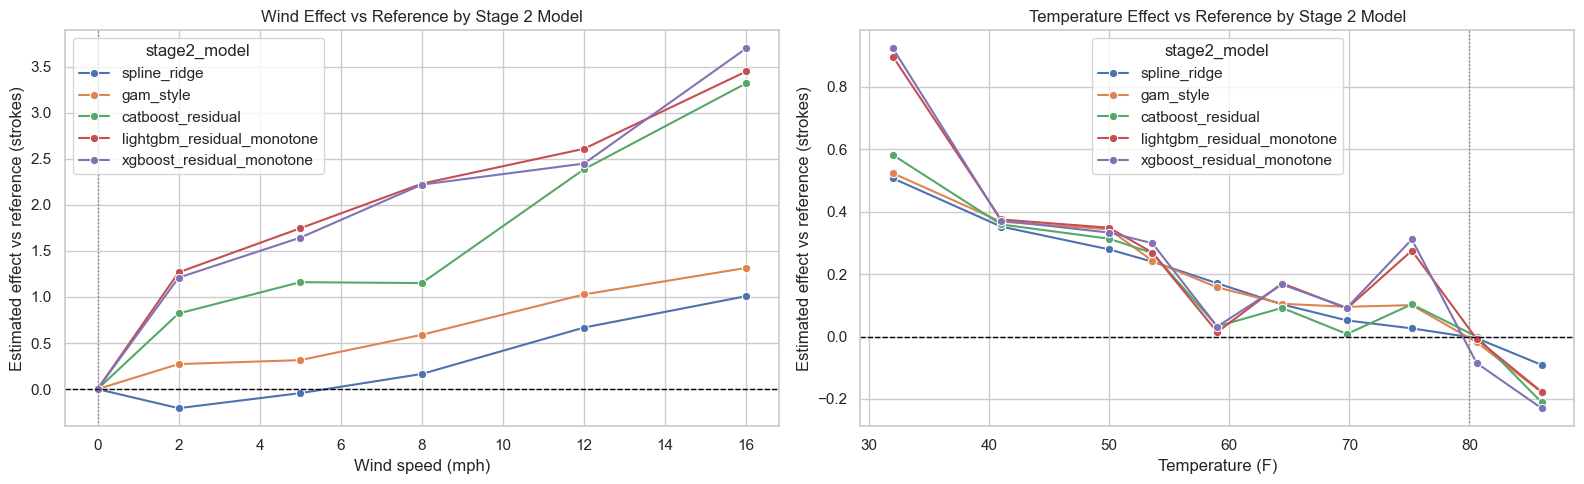

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=wind_curve_compare_df,
    x="wind_speed_mph",
    y="effect_mean",
    hue="stage2_model",
    marker="o",
    ax=axes[0],
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].axvline(REFERENCE_WIND_MPH, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Wind Effect vs Reference by Stage 2 Model")
axes[0].set_xlabel("Wind speed (mph)")
axes[0].set_ylabel("Estimated effect vs reference (strokes)")

sns.lineplot(
    data=temperature_curve_compare_df,
    x="temperature_f",
    y="effect_mean",
    hue="stage2_model",
    marker="o",
    ax=axes[1],
)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(REFERENCE_TEMPERATURE_F, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Temperature Effect vs Reference by Stage 2 Model")
axes[1].set_xlabel("Temperature (F)")
axes[1].set_ylabel("Estimated effect vs reference (strokes)")

plt.tight_layout()
plt.show()


In [34]:
# -----------------------------------------------------------------------------
# Stack scored rows across Stage 2 models
# -----------------------------------------------------------------------------

all_scored_models_df = pd.concat(
    [df.copy() for df in scored_dfs_by_model.values()],
    ignore_index=True,
)

all_scored_models_df.head()


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,round_wind_speed_mph_mean,round_wind_gust_mph_mean,round_temp_f_mean,precip_during_round_flag,observed_wind_bucket,observed_temp_bucket,stage2_model,predicted_round_strokes_stage1_baseline,predicted_weather_adjustment_observed,predicted_round_strokes,round_residual_strokes,estimated_wind_effect_vs_reference,estimated_temperature_effect_vs_reference,estimated_precip_effect_vs_reference,estimated_total_weather_effect_vs_reference
0,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,9.283301,16.777050,59.72,0,9-12,50-60,spline_ridge,80.874117,0.141427,81.015544,0.984456,0.377795,0.161227,0.000000,0.539022
1,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,6.487126,12.750558,65.12,0,6-9,60-70,spline_ridge,105.809690,-0.091134,105.718556,5.281444,0.234216,0.094765,0.000000,0.328982
2,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,6.352910,13.645334,78.98,1,6-9,70-80,spline_ridge,44.309520,-0.057343,44.252177,5.747823,0.149790,0.007637,0.167013,0.324441
3,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,8.030615,16.105968,30.02,0,6-9,30-40,spline_ridge,58.838613,0.500802,59.339414,0.660586,0.320486,0.568674,0.000000,0.889161
4,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,3.288302,6.487126,60.44,0,3-6,60-70,spline_ridge,68.039767,-0.308409,67.731359,5.268641,-0.060537,0.151834,0.000000,0.091298


In [35]:
# -----------------------------------------------------------------------------
# Effect distribution summary by Stage 2 model
# -----------------------------------------------------------------------------

effect_distribution_summary_rows = []

effect_cols = [
    "estimated_wind_effect_vs_reference",
    "estimated_temperature_effect_vs_reference",
    "estimated_precip_effect_vs_reference",
    "estimated_total_weather_effect_vs_reference",
]

for model_name, df in scored_dfs_by_model.items():
    for effect_col in effect_cols:
        effect_distribution_summary_rows.append(
            {
                "stage2_model": model_name,
                "effect_metric": effect_col,
                "mean": float(df[effect_col].mean()),
                "median": float(df[effect_col].median()),
                "std": float(df[effect_col].std()),
                "p10": float(df[effect_col].quantile(0.10)),
                "p90": float(df[effect_col].quantile(0.90)),
                "min": float(df[effect_col].min()),
                "max": float(df[effect_col].max()),
            }
        )

effect_distribution_summary_df = pd.DataFrame(effect_distribution_summary_rows)
effect_distribution_summary_df


,stage2_model,effect_metric,mean,median,std,p10,p90,min,max
0,spline_ridge,estimated_wind_effect_vs_reference,0.189487,0.088704,0.320498,-0.091362,0.639969,-0.340437,4.009155
1,spline_ridge,estimated_temperature_effect_vs_reference,0.174075,0.149500,0.183027,0.016992,0.365479,-1.072215,1.164326
2,spline_ridge,estimated_precip_effect_vs_reference,0.020255,0.000000,0.054522,0.000000,0.167013,0.000000,0.167013
3,spline_ridge,estimated_total_weather_effect_vs_reference,0.383817,0.292632,0.381069,0.014007,0.896238,-1.281413,4.528714
4,gam_style,estimated_wind_effect_vs_reference,0.594526,0.491715,0.330162,0.303181,1.019425,-0.358388,5.665088
5,gam_style,estimated_temperature_effect_vs_reference,0.196045,0.140672,0.189157,0.068376,0.412238,-0.990850,1.324261
6,gam_style,estimated_precip_effect_vs_reference,0.019843,0.000000,0.053412,0.000000,0.163613,0.000000,0.163613
7,gam_style,estimated_total_weather_effect_vs_reference,0.810415,0.728719,0.391045,0.440723,1.307370,-0.561514,6.197063
8,catboost_residual,estimated_wind_effect_vs_reference,1.622008,1.604561,0.732680,0.749411,2.500954,-2.451331,8.664031
9,catboost_residual,estimated_temperature_effect_vs_reference,0.149072,0.122641,0.418289,-0.271333,0.614446,-3.222112,4.013383


In [36]:
# -----------------------------------------------------------------------------
# Plot 2x2 histogram panel for one Stage 2 model
# -----------------------------------------------------------------------------

def plot_effect_histograms_for_model(
    scored_df: pd.DataFrame,
    *,
    model_name: str,
    bins: int = 30,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.histplot(
        scored_df["estimated_wind_effect_vs_reference"],
        bins=bins,
        ax=axes[0, 0],
        color="#1f77b4",
    )
    axes[0, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
    axes[0, 0].set_title(f"Wind Effect vs Reference ({model_name})")
    axes[0, 0].set_xlabel("strokes")
    axes[0, 0].set_ylabel("Count")

    sns.histplot(
        scored_df["estimated_temperature_effect_vs_reference"],
        bins=bins,
        ax=axes[0, 1],
        color="#ff7f0e",
    )
    axes[0, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
    axes[0, 1].set_title(f"Temperature Effect vs Reference ({model_name})")
    axes[0, 1].set_xlabel("strokes")
    axes[0, 1].set_ylabel("Count")

    sns.histplot(
        scored_df["estimated_precip_effect_vs_reference"],
        bins=bins,
        ax=axes[1, 0],
        color="#2ca02c",
    )
    axes[1, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1, 0].set_title(f"Precipitation Effect vs Reference ({model_name})")
    axes[1, 0].set_xlabel("strokes")
    axes[1, 0].set_ylabel("Count")

    sns.histplot(
        scored_df["estimated_total_weather_effect_vs_reference"],
        bins=bins,
        ax=axes[1, 1],
        color="#d62728",
    )
    axes[1, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1, 1].set_title(f"Total Weather Effect vs Reference ({model_name})")
    axes[1, 1].set_xlabel("strokes")
    axes[1, 1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


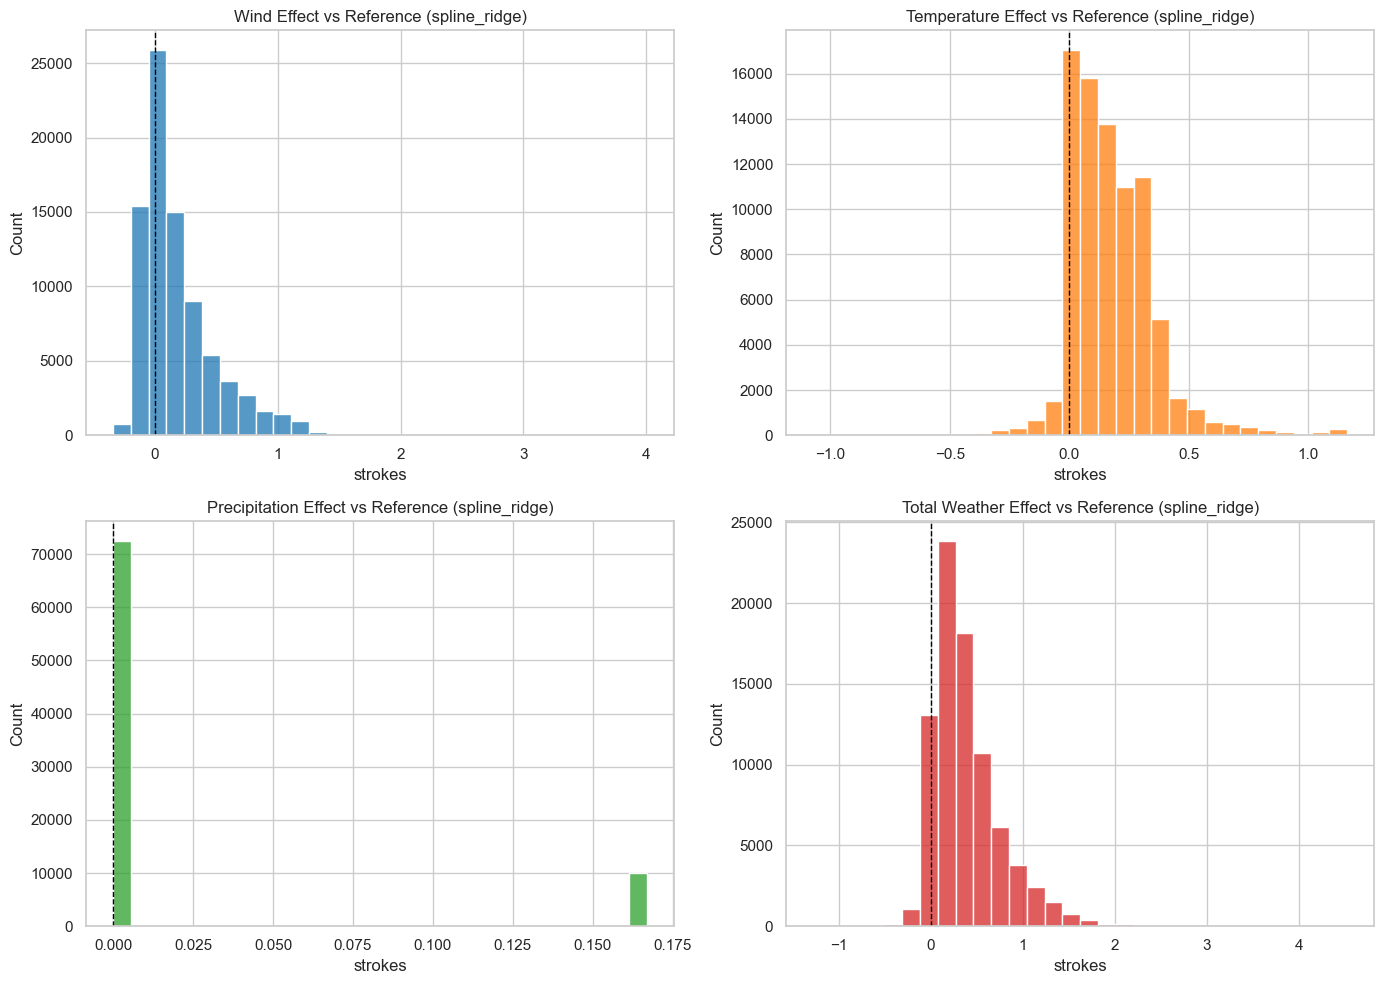

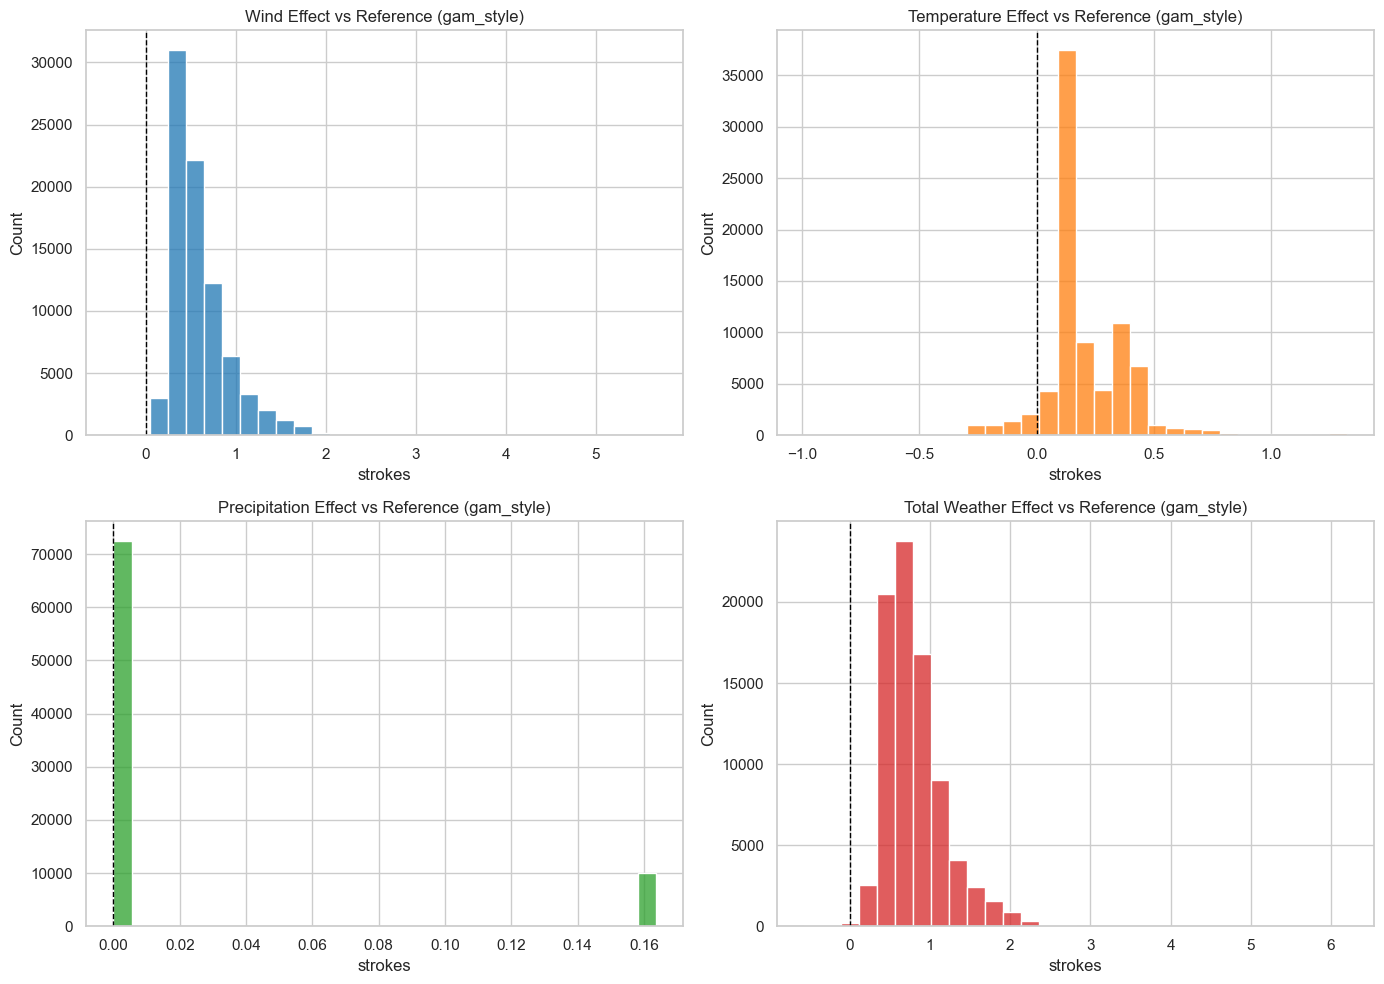

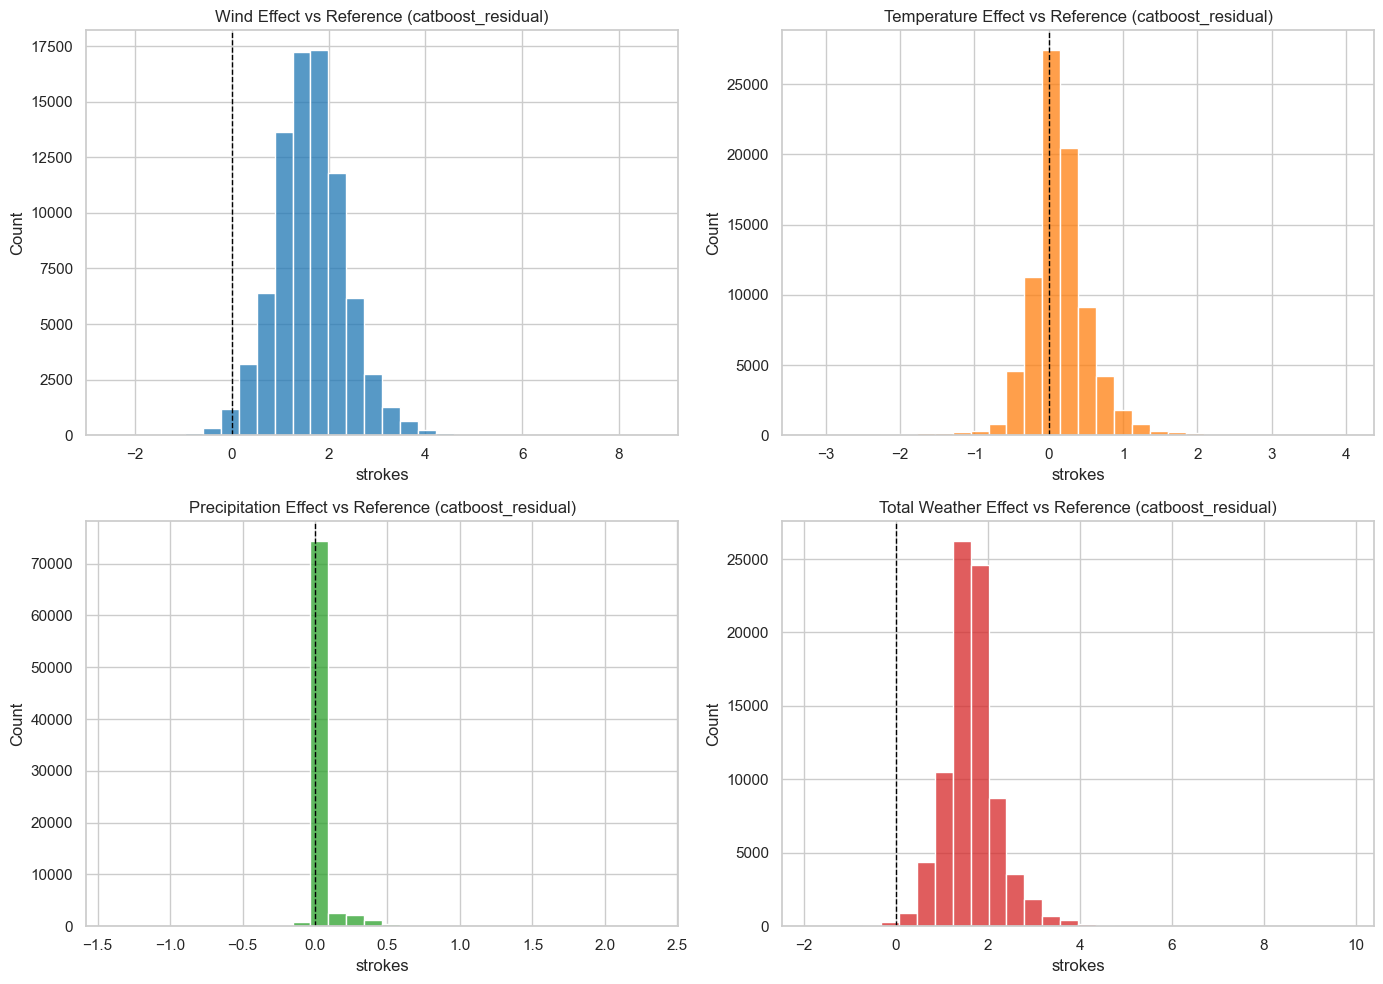

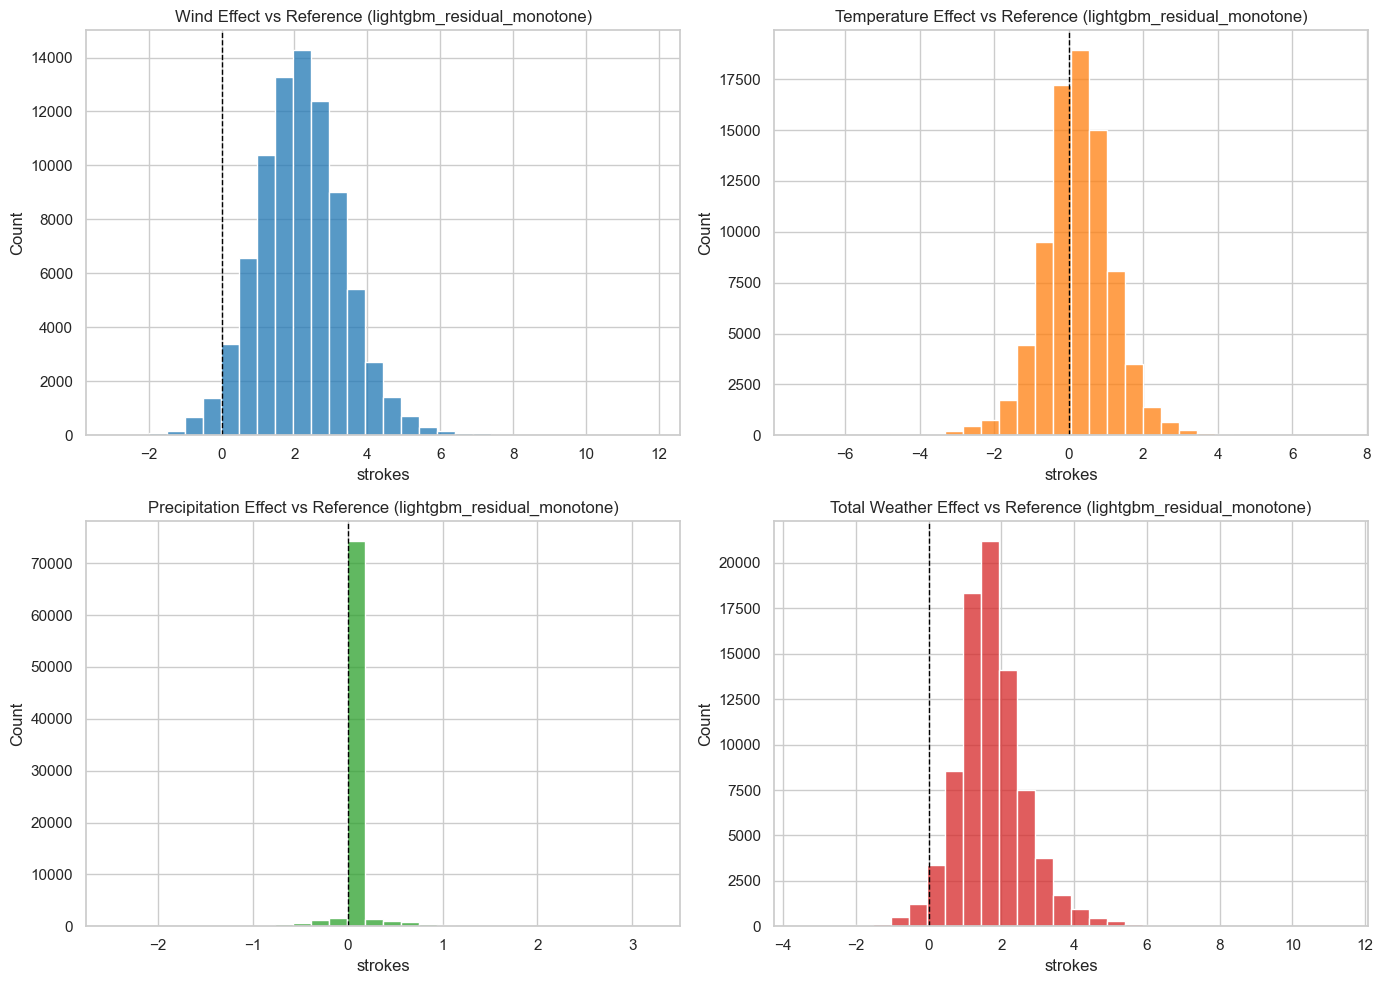

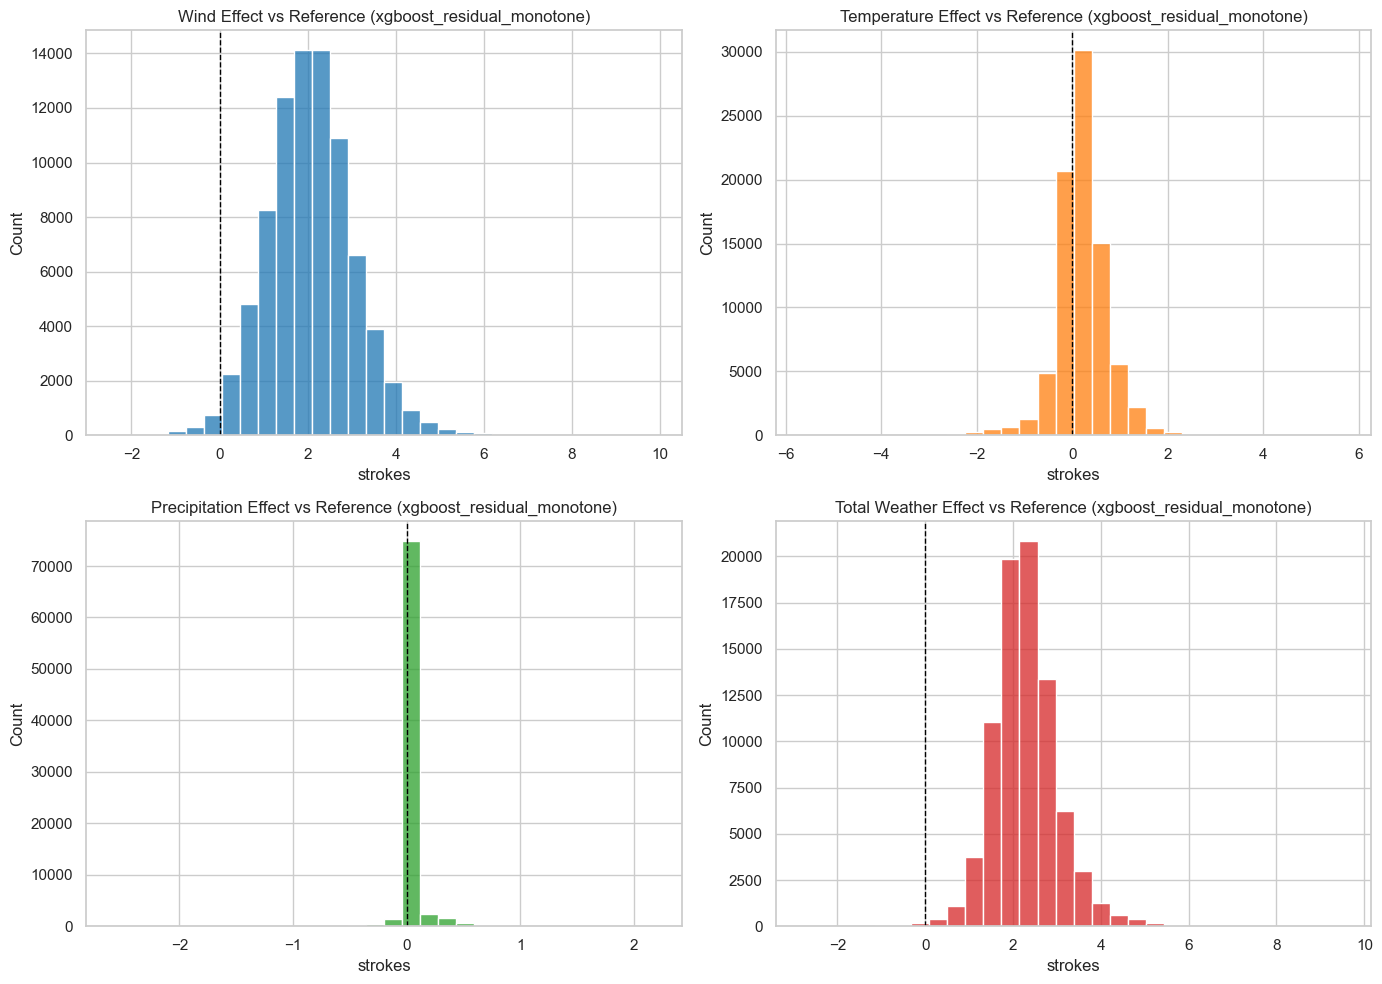

In [37]:
# -----------------------------------------------------------------------------
# Render 2x2 histogram panels for every Stage 2 model
# -----------------------------------------------------------------------------

for model_name, scored_df_model in scored_dfs_by_model.items():
    plot_effect_histograms_for_model(
        scored_df_model,
        model_name=model_name,
        bins=30,
    )


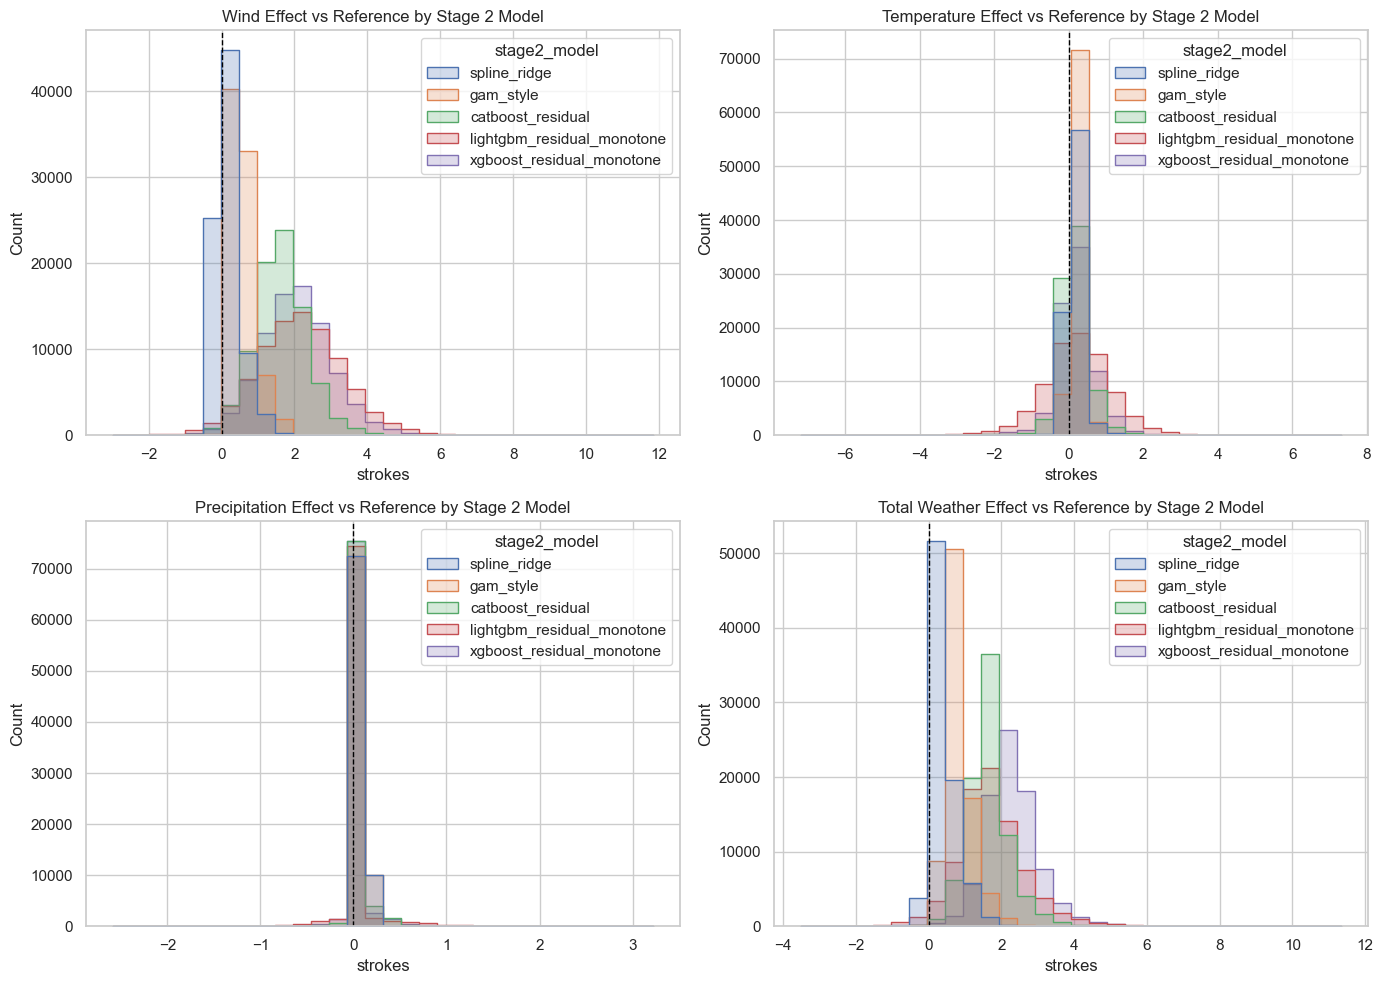

In [38]:
# -----------------------------------------------------------------------------
# Optional direct comparison histograms by model
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    data=all_scored_models_df,
    x="estimated_wind_effect_vs_reference",
    hue="stage2_model",
    bins=30,
    element="step",
    stat="count",
    common_norm=False,
    ax=axes[0, 0],
)
axes[0, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("Wind Effect vs Reference by Stage 2 Model")
axes[0, 0].set_xlabel("strokes")

sns.histplot(
    data=all_scored_models_df,
    x="estimated_temperature_effect_vs_reference",
    hue="stage2_model",
    bins=30,
    element="step",
    stat="count",
    common_norm=False,
    ax=axes[0, 1],
)
axes[0, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set_title("Temperature Effect vs Reference by Stage 2 Model")
axes[0, 1].set_xlabel("strokes")

sns.histplot(
    data=all_scored_models_df,
    x="estimated_precip_effect_vs_reference",
    hue="stage2_model",
    bins=30,
    element="step",
    stat="count",
    common_norm=False,
    ax=axes[1, 0],
)
axes[1, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Precipitation Effect vs Reference by Stage 2 Model")
axes[1, 0].set_xlabel("strokes")

sns.histplot(
    data=all_scored_models_df,
    x="estimated_total_weather_effect_vs_reference",
    hue="stage2_model",
    bins=30,
    element="step",
    stat="count",
    common_norm=False,
    ax=axes[1, 1],
)
axes[1, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Total Weather Effect vs Reference by Stage 2 Model")
axes[1, 1].set_xlabel("strokes")

plt.tight_layout()
plt.show()
